In [5]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
# Load preprocessed data
data_path = Path.cwd().parent / "shared" / "output" / "production_preprocessed_data.csv"
df = pd.read_csv(data_path, encoding='utf-8-sig')

print(f"Loaded {len(df)} rows from preprocessed data")
print(f"Participants: {df['prolific_id'].nunique()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nPhonation distribution:")
print(df['phonation'].value_counts())

Loaded 6934 rows from preprocessed data
Participants: 53

Columns: ['filename', 'label', 'rest', 'f0', 'vot', 'rest_duration', 'item', 'prolific_id', 'session_number', 'age', 'gender', 'normed_f0', 'normed_vot', 'word_duration', 'scaled_vot_by_rest_duration', 'scaled_vot', 'normed_scaled_vot', 'normed_word_duration', 'normed_rest_duration', 'log_vot', 'vowel', 'poa', 'phonation', 'syllable_structure', 'normed_age', 'age_group', 'detailed_age_group', 'log_morpheme_freq', 'log_syllable_freq', 'z_log_morpheme_freq', 'z_log_syllable_freq']

Phonation distribution:
phonation
lenis        2475
fortis       2316
aspirated    2143
Name: count, dtype: int64


참가자별 LDA 결정 경계 시각화 (확대 - 나이순 정렬, Raw 값 표시)

시각화할 참가자 수: 53명
나이 범위: 20 ~ 72세
그리드 크기: 11 행 x 5 열

✓ 그림이 고해상도로 저장되었습니다: c:\Users\hanpe\github\korean_stops_2\analysis\production\final_viz\output\lda_decision_boundaries_by_age_raw_values_highres.png


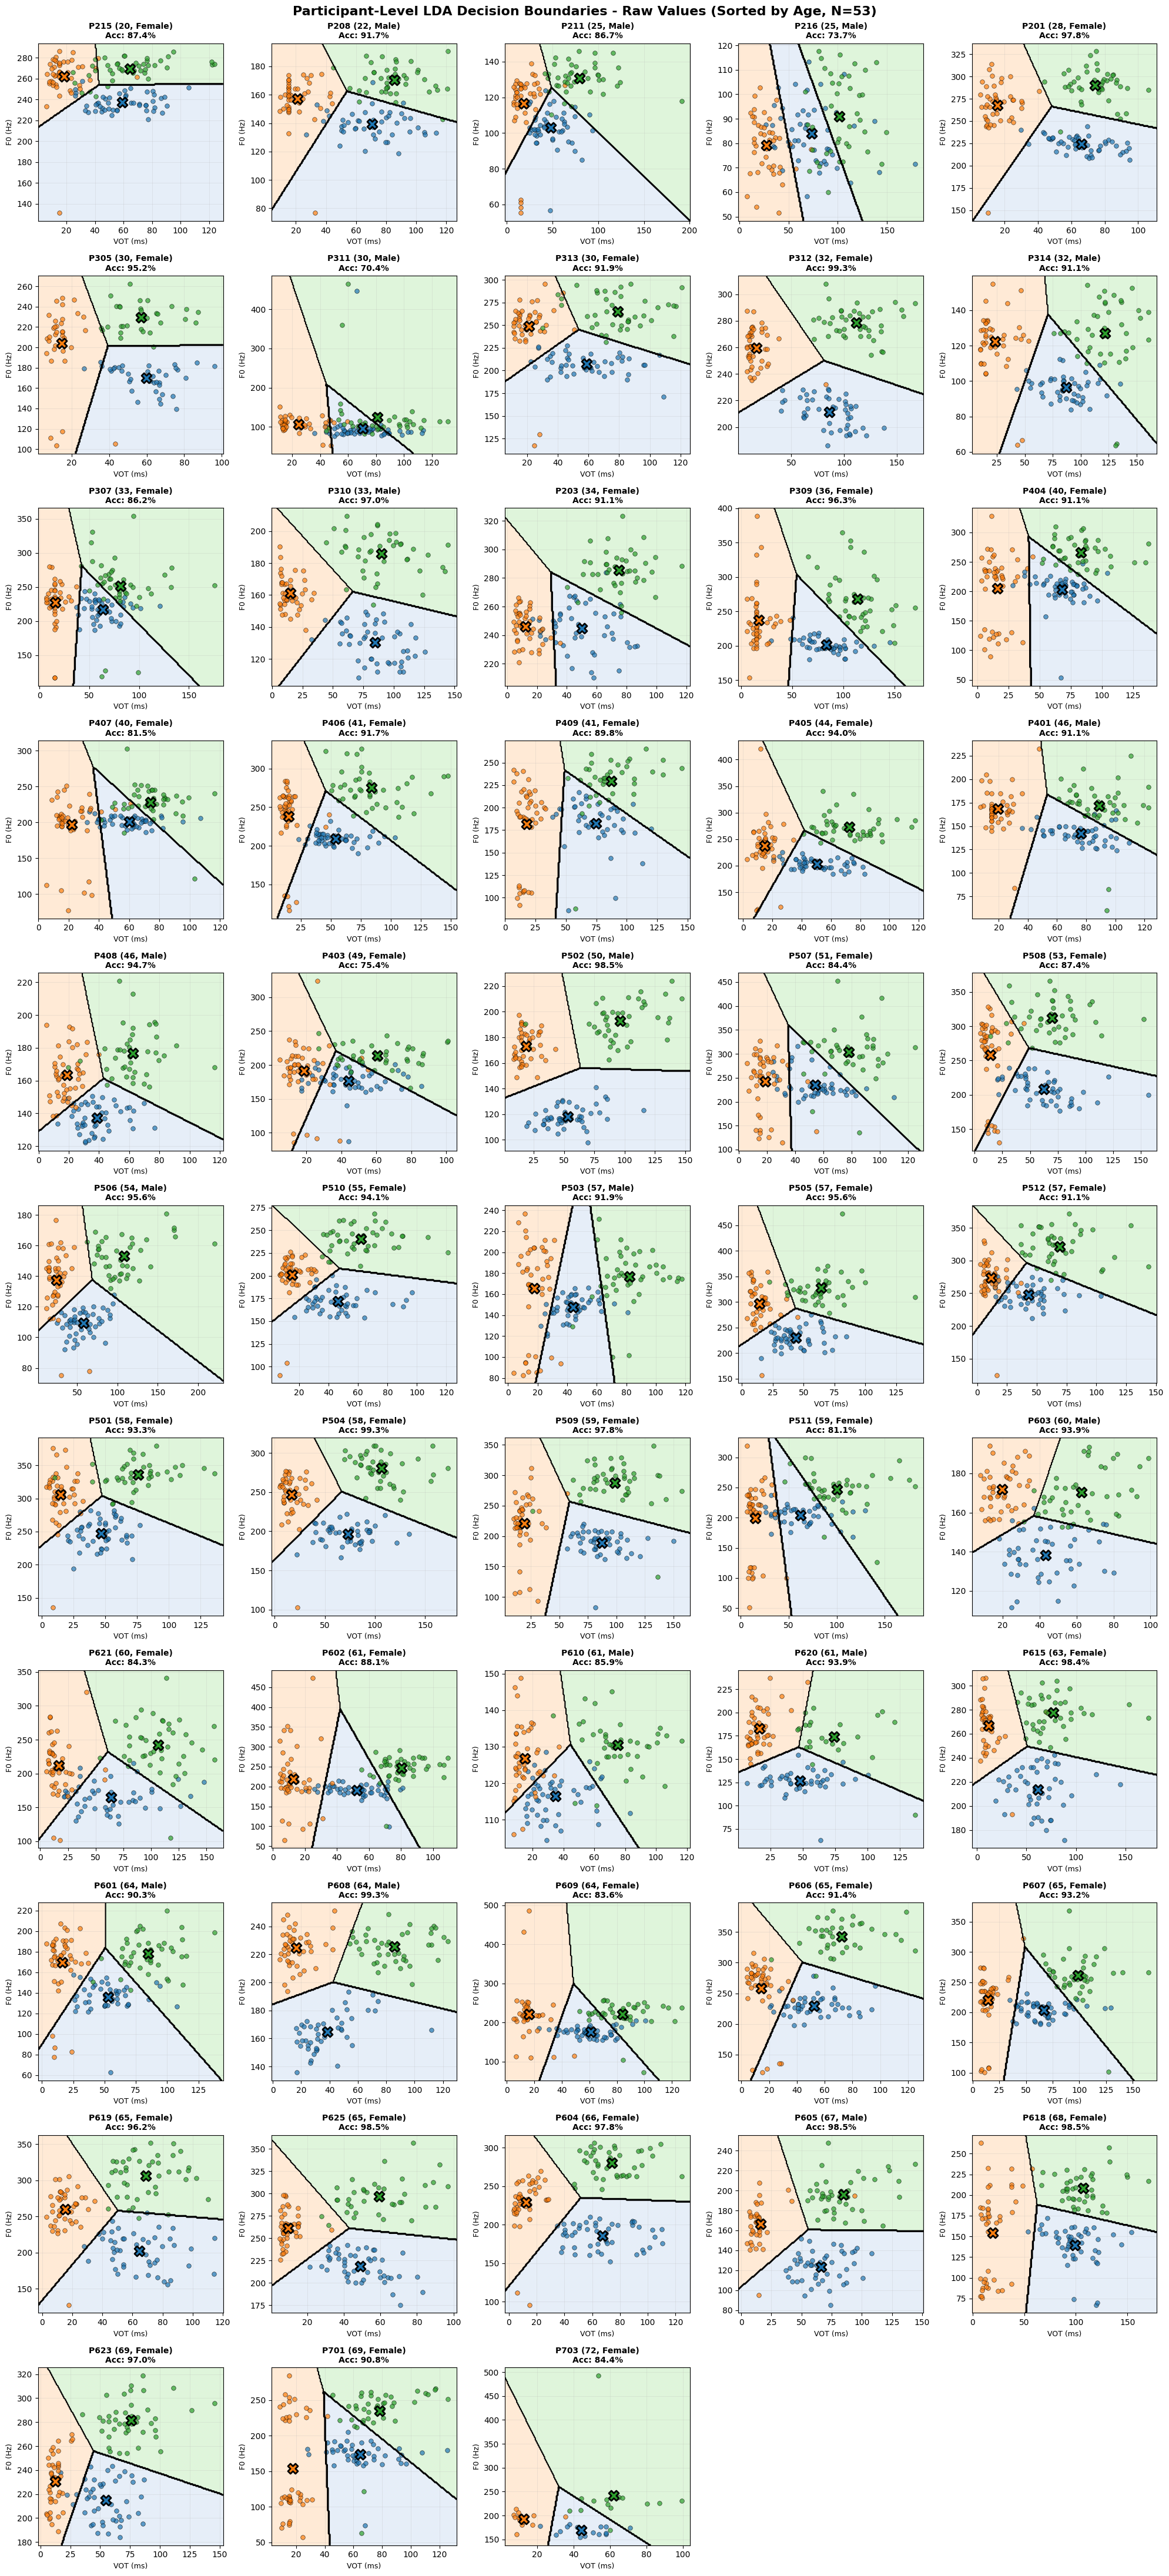


✓ 참가자별 LDA 결정 경계 시각화 완료 (나이순 정렬, Raw 값 표시)!
  - 총 53명의 참가자
  - 모델링: normed 데이터 사용 / 시각화: raw 값 표시 (VOT ms, F0 Hz)
  - 정렬: 나이 오름차순


In [7]:
# ================ 참가자별 LDA 결정 경계 시각화 (확대 - 나이순 정렬, Raw 값 표시) ================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

print("=" * 60)
print("참가자별 LDA 결정 경계 시각화 (확대 - 나이순 정렬, Raw 값 표시)")
print("=" * 60)

# 데이터 준비 (raw 값 포함)
lda_data_individual = df[['f0', 'vot', 'normed_vot', 'normed_f0', 'phonation', 'prolific_id', 'age', 'gender']].dropna().copy()

# phonation 라벨 정규화
label_alias = {'fortis': 'tense'}
lda_data_individual['phonation_clean'] = (
    lda_data_individual['phonation']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(label_alias)
)

valid_labels = ['lenis', 'tense', 'aspirated']
unknown_labels = sorted(set(lda_data_individual['phonation_clean']) - set(valid_labels))
if unknown_labels:
    print(f"경고: 예상하지 못한 phonation 라벨이 제외됩니다: {unknown_labels}")
lda_data_individual = lda_data_individual[lda_data_individual['phonation_clean'].isin(valid_labels)].copy()

# 시각화할 참가자 선택 (데이터가 충분한 참가자들)
valid_participants = []
for participant_id in lda_data_individual['prolific_id'].unique():
    participant_data = lda_data_individual[lda_data_individual['prolific_id'] == participant_id]
    phonation_counts = participant_data['phonation_clean'].value_counts()
    if len(phonation_counts) >= 3 and phonation_counts.min() >= 2:
        valid_participants.append(participant_id)

# 참가자를 나이순으로 정렬
participant_ages = {}
for participant_id in valid_participants:
    participant_data = lda_data_individual[lda_data_individual['prolific_id'] == participant_id]
    participant_ages[participant_id] = participant_data['age'].iloc[0]

valid_participants_sorted = sorted(valid_participants, key=lambda x: participant_ages[x])

print(f"\n시각화할 참가자 수: {len(valid_participants_sorted)}명")
print(f"나이 범위: {min(participant_ages.values()):.0f} ~ {max(participant_ages.values()):.0f}세")

# 색상 설정
colors_dark = {'lenis': '#1f77b4', 'tense': '#ff7f0e', 'aspirated': '#2ca02c'}
colors_light = {'lenis': '#aec7e8', 'tense': '#ffbb78', 'aspirated': '#98df8a'}
label_to_num = {'lenis': 0, 'tense': 1, 'aspirated': 2}

# 5열 그리드
n_cols = 5
n_rows = int(np.ceil(len(valid_participants_sorted) / n_cols))
print(f"그리드 크기: {n_rows} 행 x {n_cols} 열")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, participant_id in enumerate(valid_participants_sorted):
    ax = axes[idx]
    participant_data = lda_data_individual[lda_data_individual['prolific_id'] == participant_id].copy()

    # 모델링은 normed로
    X_normed = participant_data[['normed_vot', 'normed_f0']].values
    y = participant_data['phonation_clean'].values

    # normed → raw 역변환 파라미터 (meshgrid 변환용)
    vot_mean = participant_data['vot'].mean()
    vot_std  = participant_data['vot'].std()
    f0_mean  = participant_data['f0'].mean()
    f0_std   = participant_data['f0'].std()

    # 참가자별 축 범위 (여백 5% 추가)
    vot_range = participant_data['vot'].max() - participant_data['vot'].min()
    f0_range  = participant_data['f0'].max()  - participant_data['f0'].min()
    x_min = participant_data['vot'].min() - vot_range * 0.05
    x_max = participant_data['vot'].max() + vot_range * 0.05
    y_min = participant_data['f0'].min()  - f0_range  * 0.05
    y_max = participant_data['f0'].max()  + f0_range  * 0.05

    try:
        # LDA 모델 학습 (normed 데이터로)
        lda = LinearDiscriminantAnalysis()
        lda.fit(X_normed, y)

        y_pred   = lda.predict(X_normed)
        accuracy = accuracy_score(y, y_pred)

        # Meshgrid를 참가자별 raw 공간에서 생성 → normed로 변환 → LDA 예측 → raw 공간으로 시각화
        xx_raw, yy_raw = np.meshgrid(np.linspace(x_min, x_max, 200),
                                     np.linspace(y_min, y_max, 200))

        xx_normed_grid = (xx_raw - vot_mean) / vot_std
        yy_normed_grid = (yy_raw - f0_mean)  / f0_std

        Z = lda.predict(np.c_[xx_normed_grid.ravel(), yy_normed_grid.ravel()])
        Z_numeric = np.array([label_to_num[label] for label in Z]).reshape(xx_raw.shape)

        # 결정 경계 영역 + 경계선 (raw 좌표)
        cmap = plt.matplotlib.colors.ListedColormap([colors_light['lenis'],
                                                     colors_light['tense'],
                                                     colors_light['aspirated']])
        ax.contourf(xx_raw, yy_raw, Z_numeric, alpha=0.3, cmap=cmap, levels=2)
        ax.contour(xx_raw, yy_raw, Z_numeric, colors='black', linewidths=1.5, linestyles='solid', levels=2)

        # 데이터 포인트 scatter (raw 좌표)
        for phonation in ['lenis', 'tense', 'aspirated']:
            mask = (y == phonation)
            if mask.sum() > 0:
                ax.scatter(participant_data.loc[mask, 'vot'],
                           participant_data.loc[mask, 'f0'],
                           c=colors_dark[phonation], alpha=0.7, s=30,
                           edgecolors='black', linewidth=0.5)

        # 중심점 (raw 좌표)
        for phonation in ['lenis', 'tense', 'aspirated']:
            mask = (y == phonation)
            if mask.sum() > 0:
                cx = participant_data.loc[mask, 'vot'].mean()
                cy = participant_data.loc[mask, 'f0'].mean()
                ax.scatter(cx, cy, c=colors_dark[phonation], marker='X', s=150,
                           edgecolors='black', linewidth=2, zorder=5)

        participant_age    = participant_data['age'].iloc[0]
        participant_gender = participant_data['gender'].iloc[0]

        ax.set_xlabel('VOT (ms)', fontsize=9)
        ax.set_ylabel('F0 (Hz)', fontsize=9)
        ax.set_title(f'P{participant_id} ({participant_age}, {participant_gender})\nAcc: {accuracy*100:.1f}%',
                     fontsize=10, fontweight='bold')
        ax.set_xlim([x_min, x_max])
        ax.set_ylim([y_min, y_max])
        ax.grid(True, alpha=0.3, linewidth=0.5)

    except Exception as e:
        participant_age    = participant_data['age'].iloc[0] if 'age' in participant_data.columns else 'N/A'
        participant_gender = participant_data['gender'].iloc[0] if 'gender' in participant_data.columns else 'N/A'
        ax.text(0.5, 0.5, f'P{participant_id} ({participant_age}, {participant_gender})\nError: {str(e)[:30]}',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_xlim([x_min, x_max])
        ax.set_ylim([y_min, y_max])

for idx in range(len(valid_participants_sorted), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Participant-Level LDA Decision Boundaries - Raw Values (Sorted by Age, N={len(valid_participants_sorted)})',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)
output_filename = output_dir / 'lda_decision_boundaries_by_age_raw_values_highres.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ 그림이 고해상도로 저장되었습니다: {output_filename}")

plt.show()

print(f"\n✓ 참가자별 LDA 결정 경계 시각화 완료 (나이순 정렬, Raw 값 표시)!")
print(f"  - 총 {len(valid_participants_sorted)}명의 참가자")
print(f"  - 모델링: normed 데이터 사용 / 시각화: raw 값 표시 (VOT ms, F0 Hz)")
print(f"  - 정렬: 나이 오름차순")

# Equidistance analysis

Distance Variance Analysis

참가자 수: 53
Distance Variance 통계:
  Mean: 0.1088
  Std: 0.0932
  Min: 0.0001
  Max: 0.3494

✓ 히스토그램이 저장되었습니다: c:\Users\hanpe\github\korean_stops_2\analysis\production\final_viz\output\distance_variance_histogram.png


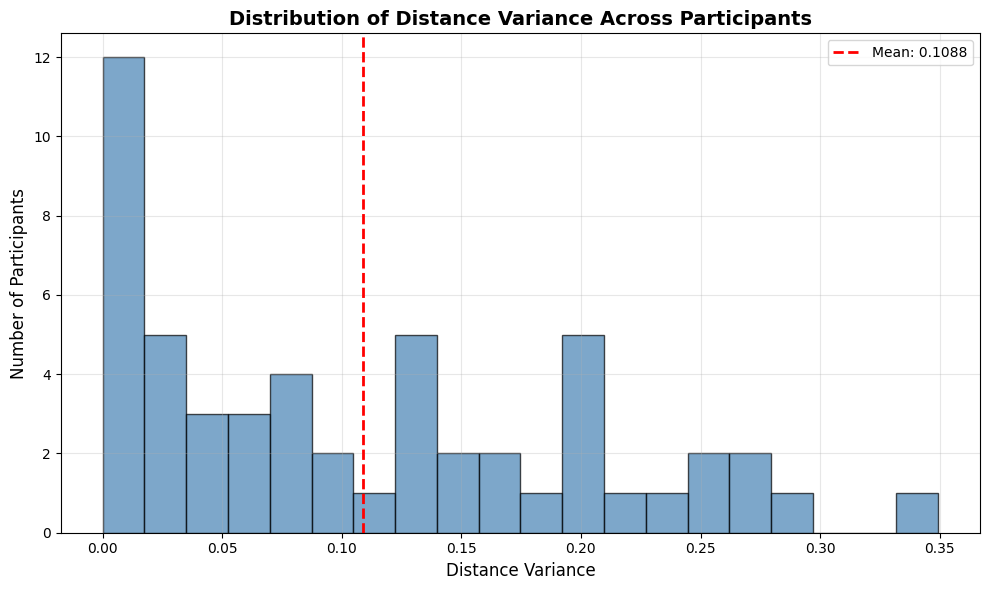


✓ Distance Variance Analysis 완료!

최대/최소 Distance Variance 참가자의 LDA 결정 경계 (Raw 값 표시)

최대 Distance Variance:
  ID: 203, DV: 0.3494
  나이: 34, 성별: Female

최소 Distance Variance:
  ID: 619, DV: 0.0001
  나이: 65, 성별: Female

✓ 비교 그래프가 저장되었습니다: c:\Users\hanpe\github\korean_stops_2\analysis\production\final_viz\output\lda_extreme_distance_variance_raw.png


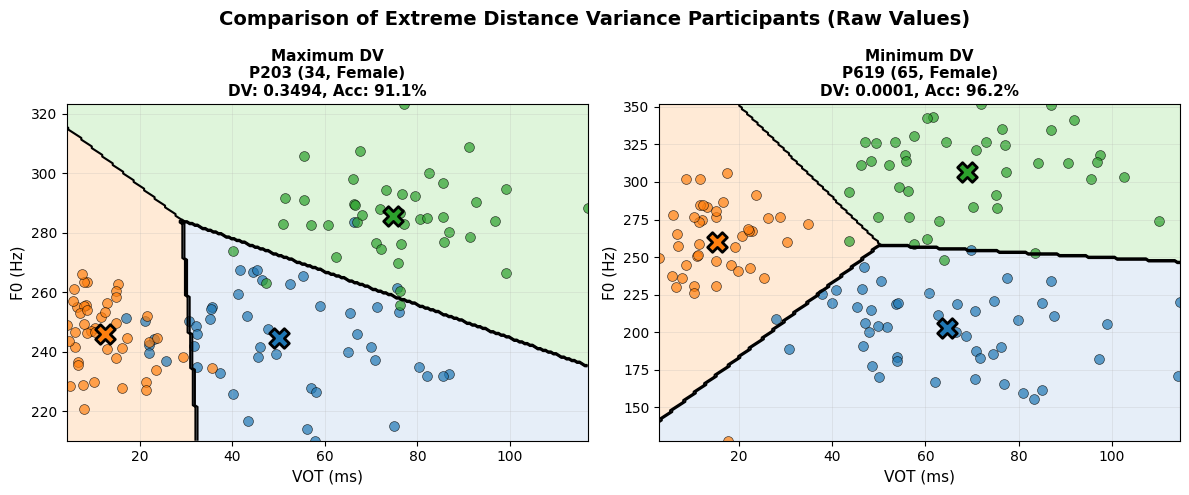


✓ 최대/최소 Distance Variance 참가자 시각화 완료 (Raw 값 표시)!


In [8]:
# ================ Distance Variance Analysis ================
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist, squareform

print("=" * 60)
print("Distance Variance Analysis")
print("=" * 60)

# 데이터 준비 (raw 값 포함)
lda_data_individual = df[['f0', 'vot', 'normed_vot', 'normed_f0', 'phonation', 'prolific_id', 'age', 'gender']].dropna().copy()

# phonation 라벨 정규화
label_alias = {'fortis': 'tense'}
lda_data_individual['phonation_clean'] = (
    lda_data_individual['phonation']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(label_alias)
)

# 예상 라벨만 사용
valid_labels = ['lenis', 'tense', 'aspirated']
lda_data_individual = lda_data_individual[lda_data_individual['phonation_clean'].isin(valid_labels)].copy()

# 각 참가자별로 distance variance 계산
distance_variances = []
participant_info = []

for participant_id in lda_data_individual['prolific_id'].unique():
    participant_data = lda_data_individual[lda_data_individual['prolific_id'] == participant_id]
    
    # 각 phonation 별로 충분한 데이터가 있는지 확인
    phonation_counts = participant_data['phonation_clean'].value_counts()
    if len(phonation_counts) < 3 or phonation_counts.min() < 1:
        continue
    
    # 각 phonation의 중점 계산 (normed로)
    centroids = {}
    for phonation in valid_labels:
        phonation_data = participant_data[participant_data['phonation_clean'] == phonation]
        centroid_vot = phonation_data['normed_vot'].mean()
        centroid_f0 = phonation_data['normed_f0'].mean()
        centroids[phonation] = np.array([centroid_vot, centroid_f0])
    
    # 중점들 사이의 거리 계산 (lenis-tense, lenis-aspirated, tense-aspirated)
    centroid_coords = np.array([centroids[label] for label in valid_labels])
    
    # 모든 쌍의 거리 계산
    distances = []
    for i in range(len(valid_labels)):
        for j in range(i+1, len(valid_labels)):
            dist = np.linalg.norm(centroid_coords[i] - centroid_coords[j])
            distances.append(dist)
    
    # 거리의 분산 계산
    distance_variance = np.var(distances)
    distance_variances.append(distance_variance)
    
    # 참가자 정보 저장
    age = participant_data['age'].iloc[0]
    gender = participant_data['gender'].iloc[0]
    participant_info.append({
        'participant_id': participant_id,
        'age': age,
        'gender': gender,
        'distance_variance': distance_variance,
        'mean_distance': np.mean(distances),
        'distances': distances
    })

# 결과 데이터프레임 생성
results_df = pd.DataFrame(participant_info)

print(f"\n참가자 수: {len(results_df)}")
print(f"Distance Variance 통계:")
print(f"  Mean: {results_df['distance_variance'].mean():.4f}")
print(f"  Std: {results_df['distance_variance'].std():.4f}")
print(f"  Min: {results_df['distance_variance'].min():.4f}")
print(f"  Max: {results_df['distance_variance'].max():.4f}")

# 히스토그램
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(results_df['distance_variance'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Distance Variance', fontsize=12)
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title('Distribution of Distance Variance Across Participants', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# 통계선 추가
mean_dv = results_df['distance_variance'].mean()
ax.axvline(mean_dv, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_dv:.4f}')
ax.legend()

plt.tight_layout()

# 저장
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)
output_filename = output_dir / 'distance_variance_histogram.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ 히스토그램이 저장되었습니다: {output_filename}")

plt.show()

print(f"\n✓ Distance Variance Analysis 완료!")

# ================ 최대/최소 Distance Variance 참가자의 LDA 시각화 (Raw 값 표시) ================
print("\n" + "=" * 60)
print("최대/최소 Distance Variance 참가자의 LDA 결정 경계 (Raw 값 표시)")
print("=" * 60)

from matplotlib.ticker import MultipleLocator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# 최대/최소 distance variance를 가진 참가자 찾기
max_idx = results_df['distance_variance'].idxmax()
min_idx = results_df['distance_variance'].idxmin()

max_participant = results_df.loc[max_idx]
min_participant = results_df.loc[min_idx]

print(f"\n최대 Distance Variance:")
print(f"  ID: {max_participant['participant_id']}, DV: {max_participant['distance_variance']:.4f}")
print(f"  나이: {max_participant['age']}, 성별: {max_participant['gender']}")

print(f"\n최소 Distance Variance:")
print(f"  ID: {min_participant['participant_id']}, DV: {min_participant['distance_variance']:.4f}")
print(f"  나이: {min_participant['age']}, 성별: {min_participant['gender']}")

# 색상 설정
colors_dark = {'lenis': '#1f77b4', 'tense': '#ff7f0e', 'aspirated': '#2ca02c'}
colors_light = {'lenis': '#aec7e8', 'tense': '#ffbb78', 'aspirated': '#98df8a'}
label_to_num = {'lenis': 0, 'tense': 1, 'aspirated': 2}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (ax, participant_row) in enumerate([(axes[0], max_participant), (axes[1], min_participant)]):
    participant_id = participant_row['participant_id']
    participant_data = lda_data_individual[lda_data_individual['prolific_id'] == participant_id].copy()
    
    # 모델링은 normed로
    X_normed = participant_data[['normed_vot', 'normed_f0']].values
    y = participant_data['phonation_clean'].values
    
    try:
        # LDA 모델 학습 (normed 데이터로)
        lda = LinearDiscriminantAnalysis()
        lda.fit(X_normed, y)
        
        # 예측 및 정확도
        y_pred = lda.predict(X_normed)
        accuracy = accuracy_score(y, y_pred)
        
        # 참가자별 raw 값의 범위 계산
        vot_min = participant_data['vot'].min()
        vot_max = participant_data['vot'].max()
        f0_min = participant_data['f0'].min()
        f0_max = participant_data['f0'].max()
        
        # 참가자별 mean과 std 계산 (역변환용)
        vot_mean = participant_data['vot'].mean()
        vot_std = participant_data['vot'].std()
        f0_mean = participant_data['f0'].mean()
        f0_std = participant_data['f0'].std()
        
        # Raw 값 범위로 meshgrid 생성
        xx_raw, yy_raw = np.meshgrid(np.linspace(vot_min, vot_max, 200),
                                     np.linspace(f0_min, f0_max, 200))
        
        # 예측을 위해 raw를 normed로 변환
        xx_normed_pred = (xx_raw - vot_mean) / vot_std
        yy_normed_pred = (yy_raw - f0_mean) / f0_std
        
        # LDA 예측 (normed로)
        Z = lda.predict(np.c_[xx_normed_pred.ravel(), yy_normed_pred.ravel()])
        Z_numeric = np.array([label_to_num[label] for label in Z])
        Z_numeric = Z_numeric.reshape(xx_raw.shape)
        
        # 결정 경계 시각화 (raw 좌표로)
        cmap = plt.matplotlib.colors.ListedColormap([colors_light['lenis'],
                                                      colors_light['tense'],
                                                      colors_light['aspirated']])
        ax.contourf(xx_raw, yy_raw, Z_numeric, alpha=0.3, cmap=cmap, levels=2)
        ax.contour(xx_raw, yy_raw, Z_numeric, colors='black', linewidths=1.5, linestyles='solid', levels=2)
        
        # 실제 데이터 포인트 (raw 값으로)
        for phonation in valid_labels:
            mask = (y == phonation)
            if mask.sum() > 0:
                ax.scatter(participant_data.loc[mask, 'vot'], participant_data.loc[mask, 'f0'],
                          c=colors_dark[phonation],
                          alpha=0.7, s=50, edgecolors='black', linewidth=0.5, label=phonation)
        
        # 중심점 표시 (raw 값으로 계산)
        for phonation in valid_labels:
            mask = (y == phonation)
            if mask.sum() > 0:
                centroid_vot = participant_data.loc[mask, 'vot'].mean()
                centroid_f0 = participant_data.loc[mask, 'f0'].mean()
                ax.scatter(centroid_vot, centroid_f0,
                          c=colors_dark[phonation], marker='X', s=200,
                          edgecolors='black', linewidth=2, zorder=5)
        
        participant_age = participant_data['age'].iloc[0]
        participant_gender = participant_data['gender'].iloc[0]
        dv = participant_row['distance_variance']
        
        # 축 라벨 (Raw 값)
        ax.set_xlabel('VOT (ms)', fontsize=11)
        ax.set_ylabel('F0 (Hz)', fontsize=11)
        
        if idx == 0:
            ax.set_title(f'Maximum DV\nP{participant_id} ({participant_age}, {participant_gender})\nDV: {dv:.4f}, Acc: {accuracy*100:.1f}%',
                        fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'Minimum DV\nP{participant_id} ({participant_age}, {participant_gender})\nDV: {dv:.4f}, Acc: {accuracy*100:.1f}%',
                        fontsize=11, fontweight='bold')
        
        # 축 범위 (raw 값 범위로)
        ax.set_xlim([vot_min, vot_max])
        ax.set_ylim([f0_min, f0_max])
        ax.grid(True, alpha=0.3, linewidth=0.5)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:50]}',
               ha='center', va='center', transform=ax.transAxes, fontsize=10)

plt.suptitle('Comparison of Extreme Distance Variance Participants (Raw Values)', fontsize=14, fontweight='bold')
plt.tight_layout()

# 저장
output_filename = output_dir / 'lda_extreme_distance_variance_raw.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ 비교 그래프가 저장되었습니다: {output_filename}")

plt.show()

print(f"\n✓ 최대/최소 Distance Variance 참가자 시각화 완료 (Raw 값 표시)!")
